In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
df=pd.read_excel('Telco_customer_churn.xlsx')

In [103]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


In [104]:
df.shape

(7043, 33)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [106]:
df['Churn Label'].value_counts()

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

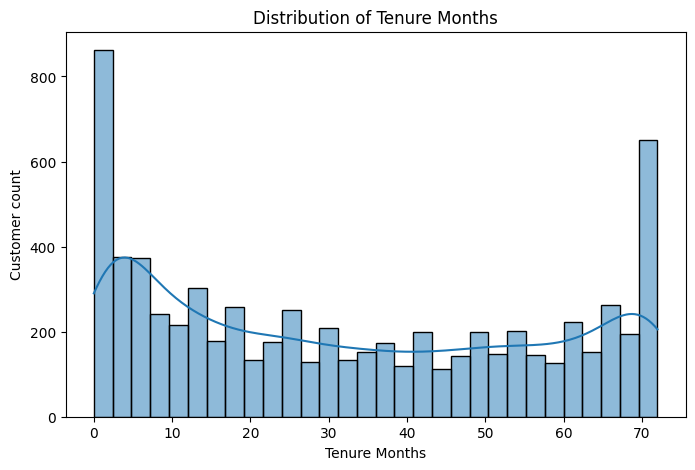

In [107]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins=30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months')
plt.show()

In [108]:
df['Tenure Months'].max()


np.int64(72)

In [109]:
df['Tenure Months'].min()

np.int64(0)

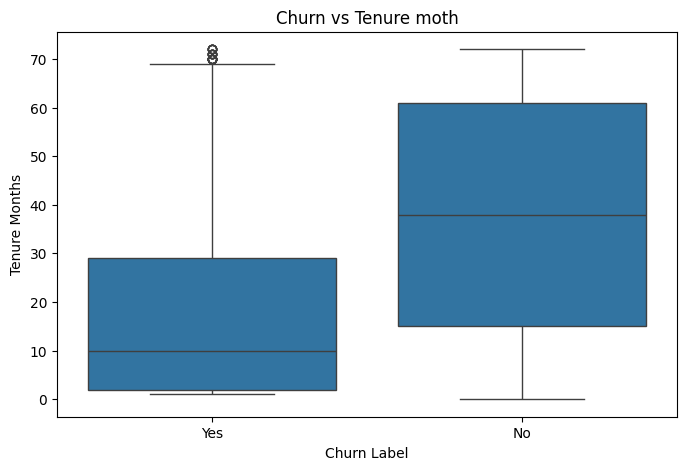

In [110]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months', data=df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn vs Tenure moth')
plt.show()

In [111]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

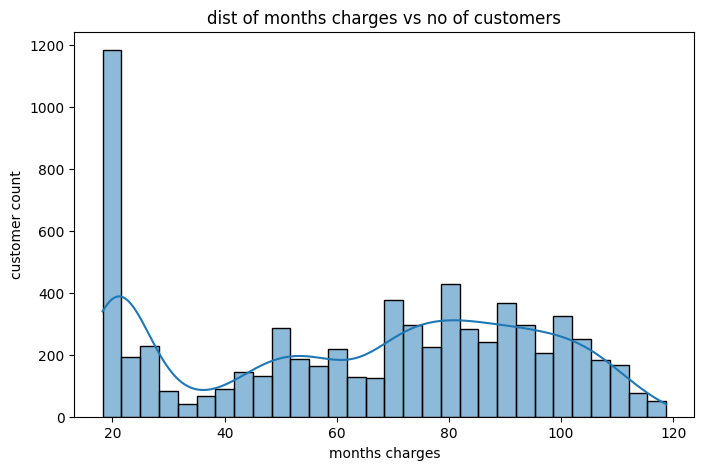

In [112]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins=30, kde=True)
plt.xlabel('months charges')
plt.ylabel('customer count')
plt.title('dist of months charges vs no of customers')
plt.show()

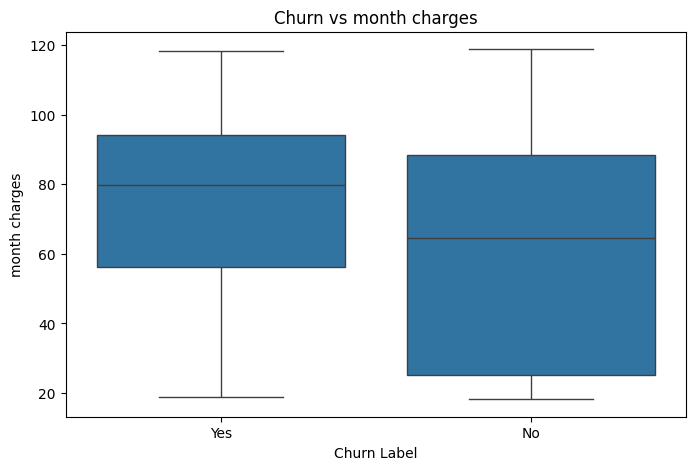

In [113]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges', data=df)
plt.xlabel('Churn Label')
plt.ylabel('month charges')
plt.title('Churn vs month charges')
plt.show()

In [114]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    25.100
0.50    64.425
0.75    88.400
Name: Monthly Charges, dtype: float64

In [115]:
df[df['Churn Label']=='Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    56.15
0.50    79.65
0.75    94.20
Name: Monthly Charges, dtype: float64

In [116]:
df['Monthly Charges'].describe()

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charges, dtype: float64

In [117]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

0.25    35.50
0.50    70.35
0.75    89.85
Name: Monthly Charges, dtype: float64

In [118]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

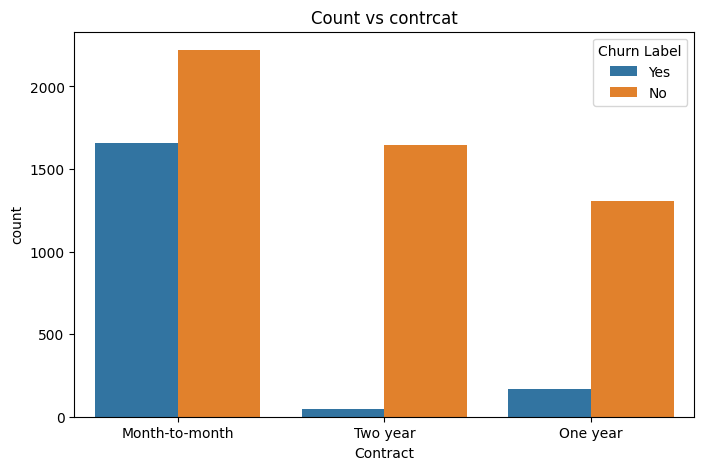

In [119]:
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('Contract')
plt.ylabel('count')
plt.title('Count vs contrcat')
plt.show()

In [120]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

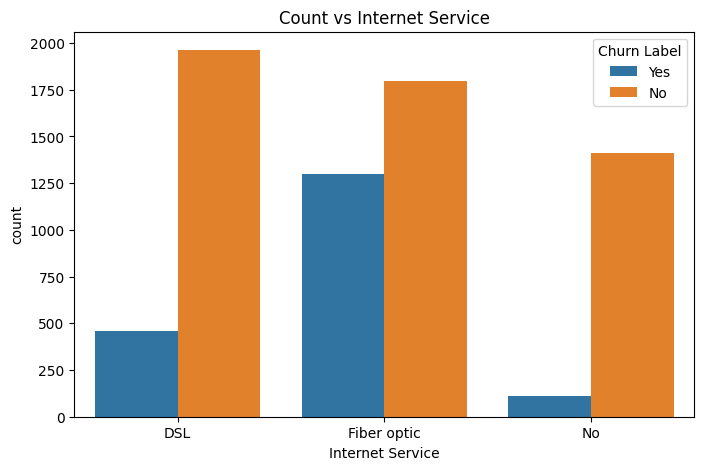

In [121]:
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Count vs Internet Service')
plt.show()

In [122]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

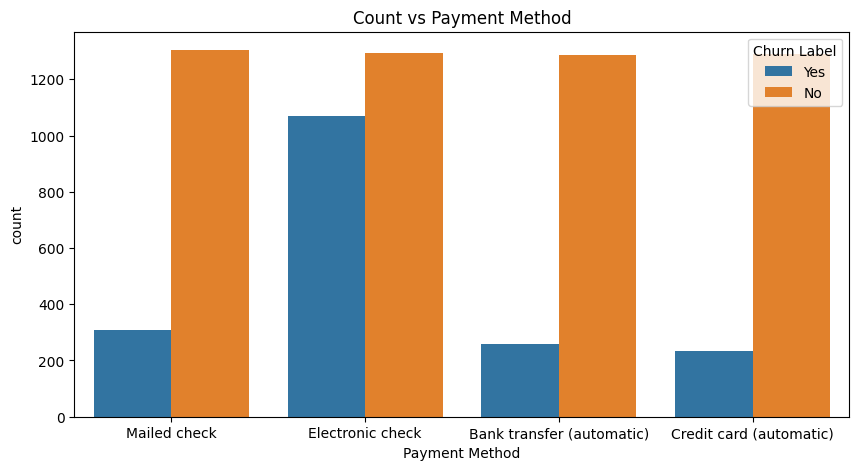

In [123]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Count vs Payment Method')
plt.show()

In [124]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

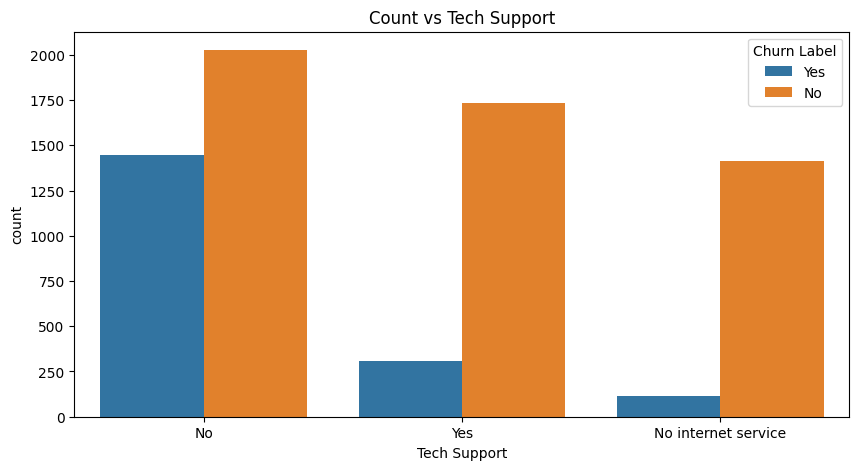

In [125]:
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Count vs Tech Support')
plt.show()

In [126]:
avg_tenure=df.groupby("Churn Label")['Tenure Months'].mean()

In [127]:
avg_tenure

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [129]:
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix=df[numerical_cols].corr()

In [130]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


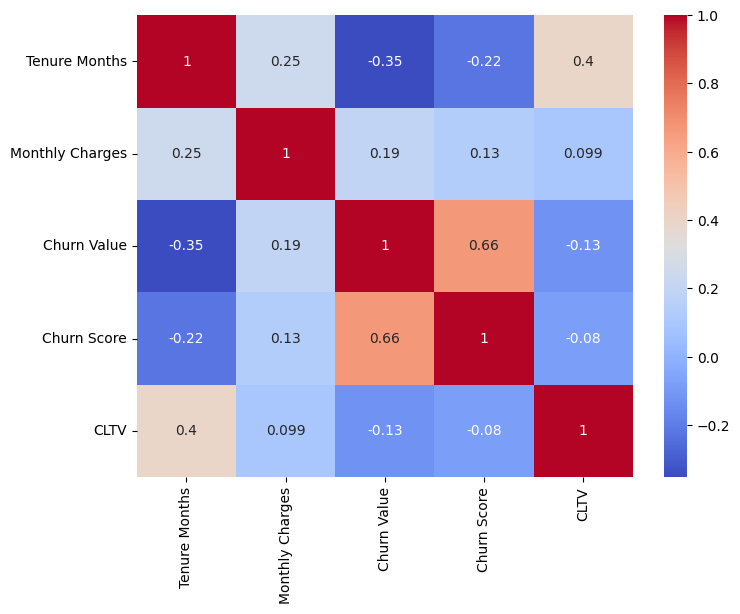

In [131]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [132]:
contract_churn=pd.crosstab(df['Contract'], df['Churn Label'], normalize='index')
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


DATA CLEANING


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [134]:
df['Total Charges']

0        108.15
1        151.65
2         820.5
3       3046.05
4        5036.3
         ...   
7038     1419.4
7039     1990.5
7040     7362.9
7041     346.45
7042     6844.5
Name: Total Charges, Length: 7043, dtype: object

In [135]:
df['Total Charges']=pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'].dtype

dtype('float64')

In [136]:
df['Total Charges']

0        108.15
1        151.65
2        820.50
3       3046.05
4       5036.30
         ...   
7038    1419.40
7039    1990.50
7040    7362.90
7041     346.45
7042    6844.50
Name: Total Charges, Length: 7043, dtype: float64

In [137]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [138]:
df['Total Charges'].dtype

dtype('float64')

In [139]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [140]:
df[df['Total Charges'].isnull()]['Tenure Months']

2234    0
2438    0
2568    0
2667    0
2856    0
4331    0
4687    0
5104    0
5719    0
6772    0
6840    0
Name: Tenure Months, dtype: int64

In [141]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [142]:
df['Total Charges']=df['Total Charges'].fillna(0)

In [143]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [144]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason']

In [145]:
df=df.drop(columns=drop_columns)

In [146]:
df.shape

(7043, 21)

In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Phone Service      7043 non-null   object 
 7   Multiple Lines     7043 non-null   object 
 8   Internet Service   7043 non-null   object 
 9   Online Security    7043 non-null   object 
 10  Online Backup      7043 non-null   object 
 11  Device Protection  7043 non-null   object 
 12  Tech Support       7043 non-null   object 
 13  Streaming TV       7043 non-null   object 
 14  Streaming Movies   7043 non-null   object 
 15  Contract           7043 non-null   object 
 16  Paperless Billing  7043 

In [148]:
print(df.columns.tolist())

['City', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [149]:
df['City'].unique()
df['City'].value_counts()

City
Los Angeles       305
San Diego         150
San Jose          112
Sacramento        108
San Francisco     104
                 ... 
Healdsburg          4
Jenner              4
Philo               4
Point Arena         4
Olympic Valley      4
Name: count, Length: 1129, dtype: int64

In [150]:
df_encoded=pd.get_dummies(df,drop_first=True)

In [151]:
df_encoded.shape

(7043, 1159)

In [152]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [153]:
df=df.drop(columns=['City'])

In [154]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [155]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [156]:
df.shape

(7043, 20)

In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [158]:
df_encoded.shape

(7043, 1159)

In [159]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,False,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,False,True,False,False,False,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,False,False,False,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False


In [160]:
x=df_encoded.drop('Churn Value',axis=1)
y=df_encoded['Churn Value']

In [161]:
x.shape
y.shape

(7043,)

In [162]:
print(x)

      Tenure Months  Monthly Charges  Total Charges  City_Acton  \
0                 2            53.85         108.15       False   
1                 2            70.70         151.65       False   
2                 8            99.65         820.50       False   
3                28           104.80        3046.05       False   
4                49           103.70        5036.30       False   
...             ...              ...            ...         ...   
7038             72            21.15        1419.40       False   
7039             24            84.80        1990.50       False   
7040             72           103.20        7362.90       False   
7041             11            29.60         346.45       False   
7042             66           105.65        6844.50       False   

      City_Adelanto  City_Adin  City_Agoura Hills  City_Aguanga  \
0             False      False              False         False   
1             False      False              False         Fal

In [163]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


MACHINE LEARNING IMPLEMENTATION

In [164]:
from sklearn.model_selection import train_test_split

In [165]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.20, random_state=42)

In [166]:
x_train.shape

(5634, 1158)

In [167]:
x_test.shape

(1409, 1158)

In [168]:
y_train.shape

(5634,)

In [169]:
y_test.shape

(1409,)

In [170]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [171]:
from sklearn.ensemble import RandomForestClassifier


In [172]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [173]:
rf_model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [174]:
y_pred = rf_model.predict(x_test)

In [175]:
y_test

185     1
2715    0
3825    0
1807    1
132     1
       ..
6366    0
315     1
2439    0
5002    0
1161    1
Name: Churn Value, Length: 1409, dtype: int64

In [176]:
y_pred

array([0, 0, 0, ..., 1, 0, 1], shape=(1409,))

In [177]:
from sklearn.metrics import accuracy_score

In [178]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.8034066713981547


In [179]:
from sklearn.metrics import confusion_matrix

In [180]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[925  84]
 [193 207]]


In [181]:
from sklearn.metrics import classification_report

In [182]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1009
           1       0.71      0.52      0.60       400

    accuracy                           0.80      1409
   macro avg       0.77      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



Approach 1- Handle Class Imbalance

In [183]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

In [184]:
rf_balanced=RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_balanced.fit(x_train,y_train)
y_pred_balanced=rf_balanced.predict(x_test)
accuracy_balanced=accuracy_score(y_test,y_pred_balanced)
cm_balanced=confusion_matrix(y_test,y_pred_balanced)
print(accuracy_balanced)
print(cm_balanced)
print(classification_report(y_test,y_pred_balanced))


0.8048261178140526
[[922  87]
 [188 212]]
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1009
           1       0.71      0.53      0.61       400

    accuracy                           0.80      1409
   macro avg       0.77      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



Approach 2 Hyperparameter Tuning

In [185]:
rf_tuned=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_tuned.fit(x_train,y_train)
y_pred_tuned=rf_tuned.predict(x_test)
accuracy_tuned=accuracy_score(y_test,y_pred_tuned)
cm_tuned=confusion_matrix(y_test,y_pred_tuned)
print(accuracy_tuned)
print(cm_tuned)
print(classification_report(y_test,y_pred_tuned))

0.7416607523066004
[[720 289]
 [ 75 325]]
              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



In [186]:
#[col for col in x.columns if col.startswith('City_')]

In [187]:
# city_cols = [col for col in x.columns if col.startswith('City_')]

# x = x.drop(columns=city_cols)

In [188]:
# [col for col in x.columns if col.startswith('City_')]

Approach 3 - Feature Importance Analysis

In [189]:
import pandas as pd

# Create the feature_importance DataFrame with all features first
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf_tuned.feature_importances_
})

# Filter out city-related features
feature_importance = feature_importance[~feature_importance['Feature'].str.startswith('City_')]

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                                     Feature  Importance
0                              Tenure Months    0.091923
1153                       Contract_Two year    0.091215
2                              Total Charges    0.070565
1134                          Dependents_Yes    0.068068
1138            Internet Service_Fiber optic    0.053864
1156         Payment Method_Electronic check    0.053524
1                            Monthly Charges    0.041273
1150    Streaming Movies_No internet service    0.040353
1147                        Tech Support_Yes    0.039385
1146        Tech Support_No internet service    0.035483
1139                     Internet Service_No    0.032190
1142       Online Backup_No internet service    0.031761
1141                     Online Security_Yes    0.030760
1144   Device Protection_No internet service    0.030009
1148        Streaming TV_No internet service    0.028732
1152                       Contract_One year    0.027986
1140     Online Security_No int

In [190]:
print('City' in df.columns)

False


In [191]:
print(df.columns.tolist())

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [192]:
print(x.columns.tolist())

['Tenure Months', 'Monthly Charges', 'Total Charges', 'City_Acton', 'City_Adelanto', 'City_Adin', 'City_Agoura Hills', 'City_Aguanga', 'City_Ahwahnee', 'City_Alameda', 'City_Alamo', 'City_Albany', 'City_Albion', 'City_Alderpoint', 'City_Alhambra', 'City_Aliso Viejo', 'City_Alleghany', 'City_Alpaugh', 'City_Alpine', 'City_Alta', 'City_Altadena', 'City_Alturas', 'City_Alviso', 'City_Amador City', 'City_Amboy', 'City_Anaheim', 'City_Anderson', 'City_Angels Camp', 'City_Angelus Oaks', 'City_Angwin', 'City_Annapolis', 'City_Antelope', 'City_Antioch', 'City_Anza', 'City_Apple Valley', 'City_Applegate', 'City_Aptos', 'City_Arbuckle', 'City_Arcadia', 'City_Arcata', 'City_Armona', 'City_Arnold', 'City_Aromas', 'City_Arroyo Grande', 'City_Artesia', 'City_Arvin', 'City_Atascadero', 'City_Atherton', 'City_Atwater', 'City_Auberry', 'City_Auburn', 'City_Avalon', 'City_Avenal', 'City_Avery', 'City_Avila Beach', 'City_Azusa', 'City_Badger', 'City_Baker', 'City_Bakersfield', 'City_Baldwin Park', 'City_

In [193]:
#[col for col in x.columns if col.startswith('City_')]

In [194]:
#[col for col in x.columns if col.startswith('City_')][:20]

In [195]:
print(feature_importance. tail(15))

                                     Feature  Importance
1152                       Contract_One year    0.027986
1140     Online Security_No internet service    0.025362
1154                   Paperless Billing_Yes    0.021813
1133                             Partner_Yes    0.014900
1155  Payment Method_Credit card (automatic)    0.014638
1132                      Senior Citizen_Yes    0.012823
1143                       Online Backup_Yes    0.010288
1145                   Device Protection_Yes    0.008933
1157             Payment Method_Mailed check    0.006365
1137                      Multiple Lines_Yes    0.004249
1149                        Streaming TV_Yes    0.004129
1151                    Streaming Movies_Yes    0.003878
1136         Multiple Lines_No phone service    0.002538
1135                       Phone Service_Yes    0.002210
1131                             Gender_Male    0.002013


In [196]:
x_selected=x.drop(['Phone Service_Yes', 'Multiple Lines_No phone service'],axis=1)

In [197]:
x_train_selected, x_test_selected, y_train, y_test=train_test_split(x_selected,y,test_size=0.2,random_state=42)


In [198]:
rf_selected=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')
rf_selected.fit(x_train_selected,y_train)
y_pred_selected=rf_selected.predict(x_test_selected)
accuracy_selected=accuracy_score(y_test,y_pred_selected)
print(classification_report(y_test,y_pred_selected))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1009
           1       0.53      0.81      0.64       400

    accuracy                           0.74      1409
   macro avg       0.72      0.76      0.72      1409
weighted avg       0.80      0.74      0.75      1409



Approach-combination of trees and depth


In [199]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [200]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,15,20,25]
results=[]
for n_estimators in n_estimators_list:
  for max_depth in max_depth_list:
    rf=RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, class_weight='balanced')
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    accuracy=accuracy_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    results.append({
        'Trees':n_estimators,
        'Depth':max_depth,
        'Accuracy':accuracy,
        'Recall':recall,
        'Precision':precision,
        'f1 score':f1
    })
results_df=pd.DataFrame(results)
results_df=results_df.sort_values(by=['Recall','Accuracy'], ascending=False)
print(results_df)



    Trees  Depth  Accuracy  Recall  Precision  f1 score
20    500      5  0.721079  0.8500   0.505201  0.633737
15    400      5  0.726757  0.8475   0.511312  0.637817
0     100      5  0.712562  0.8475   0.496340  0.626039
5     200      5  0.721079  0.8425   0.505247  0.631678
10    300      5  0.716111  0.8400   0.500000  0.626866
11    300     10  0.741661  0.8125   0.529316  0.641026
16    400     10  0.740241  0.8125   0.527597  0.639764
21    500     10  0.738112  0.8125   0.525040  0.637880
1     100     10  0.738112  0.8100   0.525122  0.637168
6     200     10  0.735983  0.8050   0.522727  0.633858
2     100     15  0.753726  0.7825   0.546248  0.643371
17    400     15  0.757275  0.7775   0.551418  0.645228
22    500     15  0.757275  0.7775   0.551418  0.645228
7     200     15  0.756565  0.7750   0.550622  0.643821
12    300     15  0.757275  0.7725   0.551786  0.643750
3     100     20  0.778566  0.7575   0.584942  0.660131
8     200     20  0.775727  0.7550   0.580769  0

In [201]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight='balanced')

In [202]:
cv_accuracy=cross_val_score(final_rf,x_train,y_train,cv=5,scoring='accuracy')
cv_recall=cross_val_score(final_rf,x_train,y_train,cv=5,scoring='recall')

In [203]:
cv_accuracy

array([0.75687666, 0.74622893, 0.75421473, 0.73469388, 0.75932504])

In [204]:
cv_recall

array([0.84353741, 0.80952381, 0.77210884, 0.80612245, 0.85665529])

In [205]:
cv_recall.mean()

np.float64(0.8175895614218384)

In [206]:
cv_accuracy.mean()

np.float64(0.7502678482776229)

In [207]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

In [208]:
y_prob=rf_tuned.predict_proba(x)

In [209]:
y_prob1=rf_tuned.predict_proba(x_test)

In [210]:
churn_probability=y_prob[:,1]

In [211]:
churn_prob=y_prob1[:,1]


In [212]:
fpr,tpr,thresholds=roc_curve(y_test,churn_prob)
auc_score=roc_auc_score(y_test,churn_prob)
print('AUC Score:',auc_score)

AUC Score: 0.8423612487611496


CUSTOMER SEGMENTATION

segmentation

In [213]:
segmentation_data=pd.DataFrame({'Tenure Months':x['Tenure Months'],
                                'Monthly charges':x['Monthly Charges'],
                                'Total Charges':x['Total Charges'],
                                'Churn probability':churn_probability})

In [214]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability
0,2,53.85,108.15,0.595694
1,2,70.70,151.65,0.699338
2,8,99.65,820.50,0.662902
3,28,104.80,3046.05,0.491876
4,49,103.70,5036.30,0.468882
...,...,...,...,...
7038,72,21.15,1419.40,0.119439
7039,24,84.80,1990.50,0.298789
7040,72,103.20,7362.90,0.347281
7041,11,29.60,346.45,0.513460


implementation of kmeans

In [215]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [216]:
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   0.78513128]
 [-1.23672422  0.19736523 -0.93887444  1.29404905]
 [-0.99240204  1.1595457  -0.64378925  1.11513788]
 [-0.17799476  1.33071079  0.3380854   0.27535952]
 [ 0.67713287  1.29415125  1.2161497   0.1624525 ]]


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

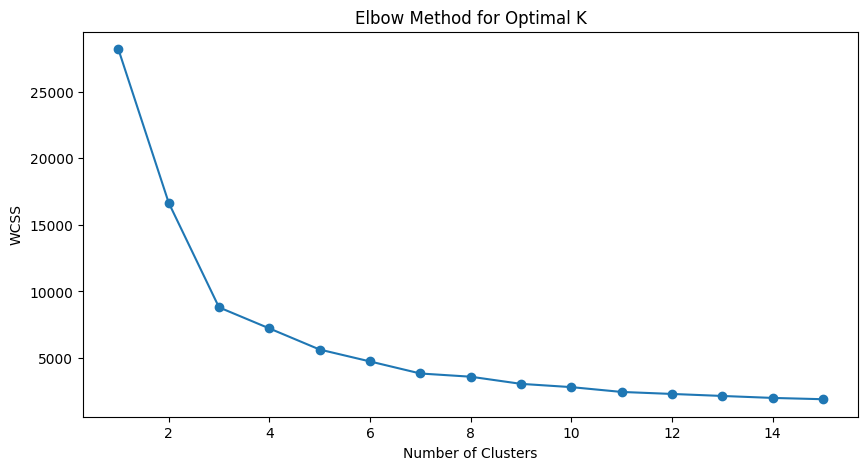

In [217]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16): #loop from 1 to 16
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(10,5))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()

In [218]:
kmeans=KMeans(n_clusters=3, random_state=42)
#segmentation_data['Cluster']=kmeans.fit_predict(scaled_data)

In [219]:
clusters=kmeans.fit_predict(scaled_data)

In [220]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability
0,2,53.85,108.15,0.595694
1,2,70.70,151.65,0.699338
2,8,99.65,820.50,0.662902
3,28,104.80,3046.05,0.491876
4,49,103.70,5036.30,0.468882
...,...,...,...,...
7038,72,21.15,1419.40,0.119439
7039,24,84.80,1990.50,0.298789
7040,72,103.20,7362.90,0.347281
7041,11,29.60,346.45,0.513460


In [221]:
segmentation_data['Cluster']=clusters

In [222]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability,Cluster
0,2,53.85,108.15,0.595694,1
1,2,70.70,151.65,0.699338,1
2,8,99.65,820.50,0.662902,1
3,28,104.80,3046.05,0.491876,1
4,49,103.70,5036.30,0.468882,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.119439,0
7039,24,84.80,1990.50,0.298789,1
7040,72,103.20,7362.90,0.347281,2
7041,11,29.60,346.45,0.513460,1


In [223]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [224]:
cluster_summary

,Tenure Months,Monthly charges,Total Charges,Churn probability
Cluster,,,,
0,31.834213,25.835216,859.535269,0.209270
1,12.712215,71.359938,956.158506,0.620323
2,58.132386,89.019813,5178.703487,0.388835


In [225]:
cluster_names={
    0:'budget loyal customer',
    1:'high risk new customer',
    2:'loyal premium customer'
}

In [226]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [227]:
segmentation_data

,Tenure Months,Monthly charges,Total Charges,Churn probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.595694,1,high risk new customer
1,2,70.70,151.65,0.699338,1,high risk new customer
2,8,99.65,820.50,0.662902,1,high risk new customer
3,28,104.80,3046.05,0.491876,1,high risk new customer
4,49,103.70,5036.30,0.468882,2,loyal premium customer
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.119439,0,budget loyal customer
7039,24,84.80,1990.50,0.298789,1,high risk new customer
7040,72,103.20,7362.90,0.347281,2,loyal premium customer
7041,11,29.60,346.45,0.513460,1,high risk new customer


<Axes: xlabel='Tenure Months', ylabel='Monthly charges'>

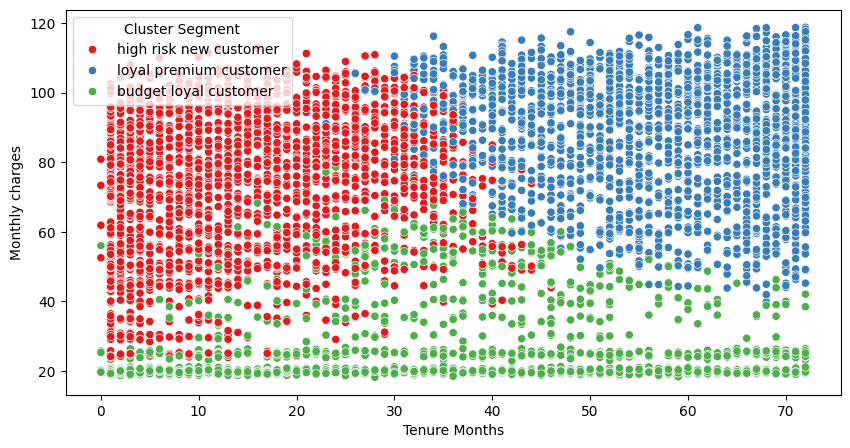

In [228]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months', y='Monthly charges', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Tenure Months', ylabel='Churn probability'>

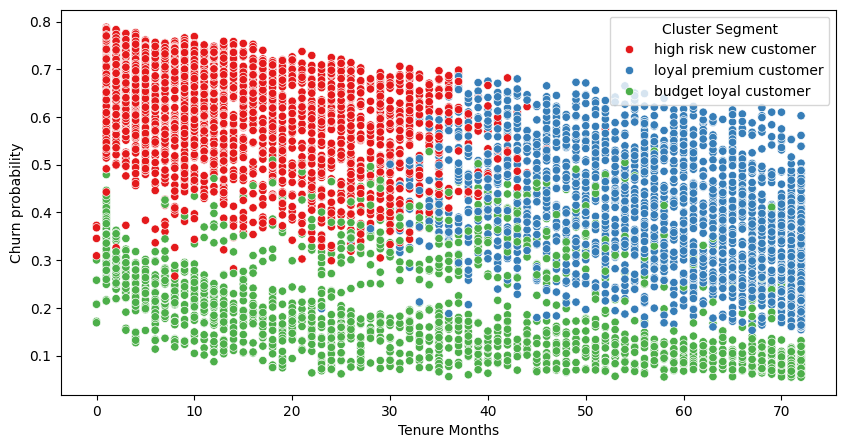

In [229]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Tenure Months', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Total Charges', ylabel='Churn probability'>

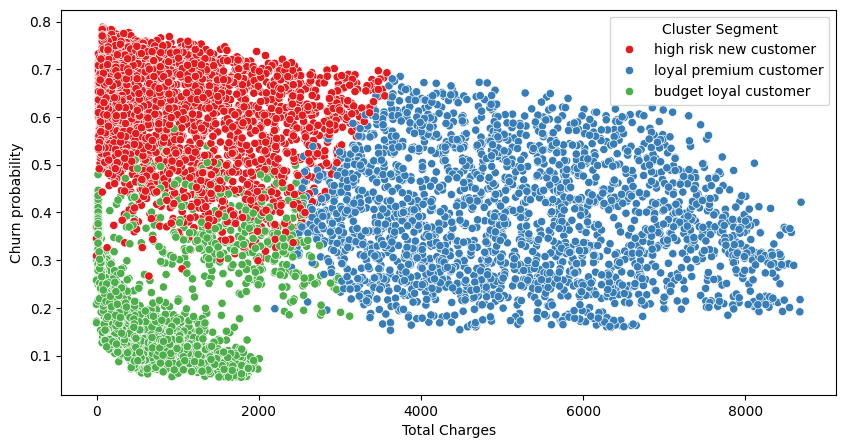

In [230]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Total Charges', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

<Axes: xlabel='Monthly charges', ylabel='Churn probability'>

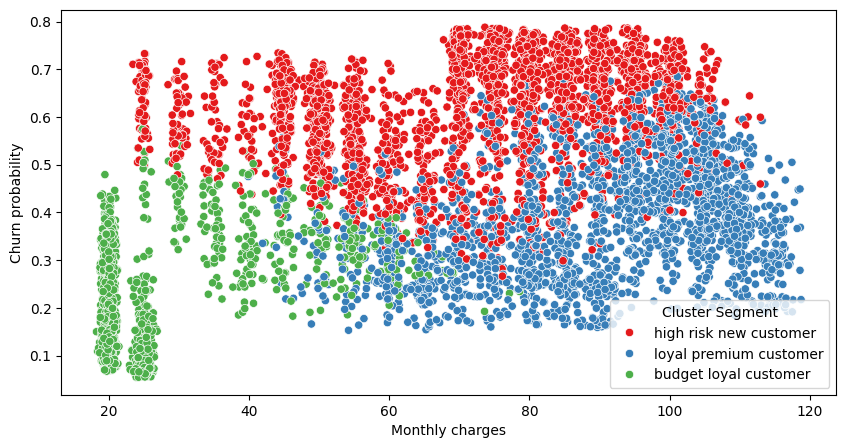

In [231]:
plt.figure(figsize=(10,5))
sns.scatterplot(x='Monthly charges', y='Churn probability', hue='Cluster Segment', data=segmentation_data, palette='Set1')

## Save Models for Deployment

Run this cell after training to export artifacts for the Streamlit app.

In [232]:
import os
import joblib

os.makedirs('models', exist_ok=True)

rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=42,
    class_weight='balanced',
)
rf_final.fit(x, y)

joblib.dump(rf_final, 'models/churn_model.joblib')
joblib.dump(list(x.columns), 'models/feature_columns.joblib')

_cities_df = pd.read_excel('Telco_customer_churn.xlsx')
joblib.dump(sorted(_cities_df['City'].unique().tolist()), 'models/cities.joblib')

churn_prob_full = rf_final.predict_proba(x)[:, 1]
segmentation_fit = pd.DataFrame({
    'Tenure Months': x['Tenure Months'],
    'Monthly Charges': x['Monthly Charges'],
    'Total Charges': x['Total Charges'],
    'Churn probability': churn_prob_full,
})

scaler_final = StandardScaler()
scaled_seg = scaler_final.fit_transform(segmentation_fit)
kmeans_final = KMeans(n_clusters=3, random_state=42)
kmeans_final.fit(scaled_seg)

cluster_names = {
    0: 'budget loyal customer',
    1: 'high risk new customer',
    2: 'loyal premium customer',
}

joblib.dump(scaler_final, 'models/scaler.joblib')
joblib.dump(kmeans_final, 'models/kmeans.joblib')
joblib.dump(cluster_names, 'models/cluster_names.joblib')

print('Saved to models/: churn_model, feature_columns, cities, scaler, kmeans, cluster_names')

Saved to models/: churn_model, feature_columns, cities, scaler, kmeans, cluster_names
